# Causal Inference on a Kaggle Social Media / Digital Marketing Dataset

This notebook is generated by `create_causal_inference_notebook.py`.

## Goal
Estimate the effect of a **binary intervention / treatment** on an **observed outcome** using biased observational data, then compare three approaches:

1. **Inverse Probability Weighting (IPW)**
2. **Propensity Score Matching (PSM)**
3. **Doubly Robust / AIPW**

It also includes:
- exploratory plots
- covariate balance checks **before** and **after** adjustment
- effect estimation for both **continuous** and **binary** outcomes
- a final regression model on the adjusted / matched data

## Important note
With a real observational dataset, the **true causal effect is not observed**.  
So the notebook estimates a **best-supported causal effect under assumptions** rather than a known ground-truth effect.

## Suggested Kaggle datasets
This notebook is designed to work well with digital marketing / social media datasets such as:
- **Predict Conversion in Digital Marketing Dataset** on Kaggle, which includes demographic and campaign interaction fields for customer conversion analysis. citeturn424110search7turn424110search13
- **Social Media Advertising Dataset** on Kaggle, which includes ad impressions, clicks, spend, demographic targeting, and conversion-related metrics. citeturn424110search3

Download the CSV from Kaggle first, then set the file path and column names below.


In [1]:
# If needed, uncomment:
# !pip install pandas numpy matplotlib seaborn scikit-learn statsmodels nbformat


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from dataclasses import dataclass

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score

import statsmodels.api as sm
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")


In [3]:

# # =========================
# # USER CONFIGURATION
# # =========================

# DATA_PATH = "digital_marketing_campaign_dataset.csv"

# # Pick a binary treatment column if the dataset already has one, for example:
# # "saw_video_ad", "clicked_ad", "high_exposure", "retargeted", etc.
# # If treatment_col is None, the notebook can derive one from treatment_source_col.
# treatment_col = None

# # If no binary treatment column exists, derive a treatment from a numeric exposure/intensity column.
# # Example: "AdExposure", "Clicks", "Impressions", "Spent"
# treatment_source_col = None

# # How to turn treatment_source_col into binary treatment:
# # "median", "upper_quartile", or provide a numeric threshold.
# treatment_rule = "median"

# # Outcome column: can be binary (e.g. Conversion) or continuous (e.g. Revenue, CTR, Sales)
# outcome_col = None

# # Optional columns to drop even if they exist
# drop_cols = []

# # Optional explicit covariates list.
# # If None, notebook will infer covariates as all non-treatment/non-outcome columns.
# covariate_cols = None

# # Optional: set an ID column if present
# id_col = None

# # Limit high-cardinality categoricals to avoid huge one-hot matrices
# MAX_CATEGORY_LEVELS = 30

# # Matching settings
# MATCH_REPLACEMENT = False
# CALIPER_STD = 0.2  # caliper in SD units of the propensity score logit


In [11]:
DATA_PATH = "digital_marketing_campaign_dataset.csv"

outcome_col = "Conversion"

treatment_col = None
treatment_source_col = "AdSpend"
treatment_rule = "median"

covariate_cols = [
    "Age",
    "Gender",
    "Income",
    "CampaignChannel",
    "CampaignType",
    "WebsiteVisits",
    "PagesPerVisit",
    "TimeOnSite",
    "SocialShares",
    "EmailOpens",
    "EmailClicks",
    "PreviousPurchases",
    "LoyaltyPoints",
    "AdvertisingPlatform",
    "AdvertisingTool"
]

id_col = "CustomerID"
drop_cols = []

In [12]:

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

print("\nColumns:")
print(df.columns.tolist())


Shape: (8000, 20)


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1



Columns:
['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel', 'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'AdvertisingPlatform', 'AdvertisingTool', 'Conversion']


In [13]:
def make_binary(series):
    s = series.copy()
    if pd.api.types.is_bool_dtype(s):
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        vals = sorted(pd.Series(s.dropna().unique()).tolist())
        if set(vals).issubset({0, 1}):
            return s.astype(int)
    if s.dtype == "object":
        mapped = s.astype(str).str.lower().str.strip()
        truthy = {"yes", "y", "true", "1", "treated", "treatment", "converted"}
        falsy = {"no", "n", "false", "0", "control", "not converted"}
        if mapped.isin(truthy | falsy).all():
            return mapped.map(lambda x: 1 if x in truthy else 0)
    raise ValueError("Could not convert series to binary.")

def derive_treatment_from_numeric(series, rule="median"):
    s = pd.to_numeric(series, errors="coerce")
    if isinstance(rule, (int, float)):
        return (s >= rule).astype(int)
    if rule == "median":
        thr = s.median()
        print(f"Using median threshold for treatment: {thr:.4f}")
        return (s >= thr).astype(int)
    if rule == "upper_quartile":
        thr = s.quantile(0.75)
        print(f"Using upper quartile threshold for treatment: {thr:.4f}")
        return (s >= thr).astype(int)
    raise ValueError("treatment_rule must be 'median', 'upper_quartile', or a numeric threshold.")

def infer_covariates(df, treatment, outcome, id_col=None, drop_cols=None):
    drop_cols = set(drop_cols or [])
    excluded = {treatment, outcome} | drop_cols
    if id_col is not None:
        excluded.add(id_col)
    cols = [c for c in df.columns if c not in excluded]
    selected = []
    for c in cols:
        nunique = df[c].nunique(dropna=True)
        if nunique <= 1:
            continue
        if df[c].dtype == "object" and nunique > MAX_CATEGORY_LEVELS:
            continue
        selected.append(c)
    return selected

def detect_outcome_type(series):
    s = series.dropna()
    if pd.api.types.is_bool_dtype(s):
        return "binary"
    if pd.api.types.is_numeric_dtype(s):
        vals = set(pd.Series(s.unique()).tolist())
        if vals.issubset({0, 1}):
            return "binary"
        return "continuous"
    return "continuous"

def split_columns(df, covariates):
    numeric = [c for c in covariates if pd.api.types.is_numeric_dtype(df[c])]
    categorical = [c for c in covariates if c not in numeric]
    return numeric, categorical

def build_preprocessor(df, covariates):
    numeric, categorical = split_columns(df, covariates)
    transformers = []
    if numeric:
        transformers.append((
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric
        ))
    if categorical:
        transformers.append((
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical
        ))
    return ColumnTransformer(transformers), numeric, categorical

def standardized_mean_difference(x_t, x_c):
    x_t = pd.Series(x_t).dropna()
    x_c = pd.Series(x_c).dropna()
    v = 0.5 * (x_t.var(ddof=1) + x_c.var(ddof=1))
    if v == 0 or np.isnan(v):
        return 0.0
    return (x_t.mean() - x_c.mean()) / np.sqrt(v)

def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)

def weighted_var(x, w):
    mu = weighted_mean(x, w)
    return np.sum(w * (x - mu) ** 2) / np.sum(w)

def weighted_smd(x_t, x_c, w_t, w_c):
    x_t = np.asarray(x_t)
    x_c = np.asarray(x_c)
    w_t = np.asarray(w_t)
    w_c = np.asarray(w_c)
    mt = weighted_mean(x_t, w_t)
    mc = weighted_mean(x_c, w_c)
    vt = weighted_var(x_t, w_t)
    vc = weighted_var(x_c, w_c)
    pooled = 0.5 * (vt + vc)
    if pooled == 0 or np.isnan(pooled):
        return 0.0
    return (mt - mc) / np.sqrt(pooled)

def compute_numeric_balance_table(df, treatment_col, numeric_covariates, weights=None):
    rows = []
    treated = df[treatment_col] == 1
    control = df[treatment_col] == 0

    for col in numeric_covariates:
        x_t = df.loc[treated, col]
        x_c = df.loc[control, col]
        if weights is None:
            smd = standardized_mean_difference(x_t, x_c)
        else:
            wt = weights.loc[treated]
            wc = weights.loc[control]
            smd = weighted_smd(x_t.fillna(x_t.median()), x_c.fillna(x_c.median()), wt, wc)
        rows.append({
            "covariate": col,
            "treated_mean": x_t.mean(),
            "control_mean": x_c.mean(),
            "abs_smd": abs(smd)
        })
    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)

def plot_love(df_before, df_after, title):
    merged = df_before[["covariate", "abs_smd"]].merge(
        df_after[["covariate", "abs_smd"]],
        on="covariate",
        suffixes=("_before", "_after")
    )
    merged = merged.sort_values("abs_smd_before", ascending=True)
    plt.figure(figsize=(9, max(4, 0.3 * len(merged))))
    plt.scatter(merged["abs_smd_before"], merged["covariate"], label="Before")
    plt.scatter(merged["abs_smd_after"], merged["covariate"], label="After")
    plt.axvline(0.1, linestyle="--")
    plt.xlabel("Absolute standardized mean difference")
    plt.ylabel("Covariate")
    plt.title(title)
    plt.legend()
    plt.show()
    return merged.sort_values("abs_smd_before", ascending=False)

def add_ps_logit(df, ps):
    eps = 1e-6
    ps = np.clip(ps, eps, 1 - eps)
    out = df.copy()
    out["propensity_score"] = ps
    out["ps_logit"] = np.log(ps / (1 - ps))
    return out

def ipw_ate(y, t, ps, stabilized=True):
    eps = 1e-6
    ps = np.clip(np.asarray(ps), eps, 1 - eps)
    t = np.asarray(t)
    y = np.asarray(y)
    p_t = t.mean()
    if stabilized:
        w = np.where(t == 1, p_t / ps, (1 - p_t) / (1 - ps))
    else:
        w = np.where(t == 1, 1 / ps, 1 / (1 - ps))
    mu1 = np.sum(w * t * y) / np.sum(w * t)
    mu0 = np.sum(w * (1 - t) * y) / np.sum(w * (1 - t))
    ate = mu1 - mu0
    return ate, w, mu1, mu0

def fit_outcome_models(X_proc, y, t, outcome_type):
    X1 = np.hstack([X_proc, np.ones((X_proc.shape[0], 1))])
    X0 = np.hstack([X_proc, np.zeros((X_proc.shape[0], 1))])
    X_obs = np.hstack([X_proc, t.reshape(-1, 1)])

    if outcome_type == "binary":
        m = LogisticRegression(max_iter=3000)
        m.fit(X_obs, y)
        mu1 = m.predict_proba(X1)[:, 1]
        mu0 = m.predict_proba(X0)[:, 1]
        return m, mu1, mu0
    else:
        m = LinearRegression()
        m.fit(X_obs, y)
        mu1 = m.predict(X1)
        mu0 = m.predict(X0)
        return m, mu1, mu0

def aipw_ate(y, t, ps, mu1, mu0):
    eps = 1e-6
    ps = np.clip(np.asarray(ps), eps, 1 - eps)
    y = np.asarray(y)
    t = np.asarray(t)
    mu1 = np.asarray(mu1)
    mu0 = np.asarray(mu0)
    pseudo = mu1 - mu0 + t * (y - mu1) / ps - (1 - t) * (y - mu0) / (1 - ps)
    return pseudo.mean(), pseudo

def propensity_score_matching(df, treatment_col, outcome_col, caliper_std=0.2, replacement=False):
    treated = df[df[treatment_col] == 1].copy()
    control = df[df[treatment_col] == 0].copy()

    if len(treated) == 0 or len(control) == 0:
        raise ValueError("Need both treated and control units.")

    caliper = caliper_std * df["ps_logit"].std()
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[["ps_logit"]])
    distances, indices = nn.kneighbors(treated[["ps_logit"]])

    matches = []
    used_controls = set()

    for t_idx, dist, idx in zip(treated.index, distances.flatten(), indices.flatten()):
        c_idx = control.index[idx]
        if dist > caliper:
            continue
        if (not replacement) and (c_idx in used_controls):
            continue
        matches.append((t_idx, c_idx, dist))
        used_controls.add(c_idx)

    if not matches:
        raise ValueError("No matches found under the current caliper settings.")

    treated_idx = [m[0] for m in matches]
    control_idx = [m[1] for m in matches]

    matched = pd.concat([
        df.loc[treated_idx].assign(match_group="treated"),
        df.loc[control_idx].assign(match_group="control")
    ], axis=0).copy()

    pair_df = pd.DataFrame(matches, columns=["treated_index", "control_index", "distance"])
    return matched, pair_df

def effect_from_groups(df, treatment_col, outcome_col):
    y1 = df.loc[df[treatment_col] == 1, outcome_col]
    y0 = df.loc[df[treatment_col] == 0, outcome_col]
    return y1.mean() - y0.mean(), y1.mean(), y0.mean()

def summarize_effects(results):
    return pd.DataFrame(results).sort_values("method")


In [14]:
# Build / validate treatment
work = df.copy()

# Case 1: user already has a treatment column in the raw data
if treatment_col is not None and treatment_col in work.columns:
    work["treatment"] = make_binary(work[treatment_col])

# Case 2: user wants to derive treatment from an existing numeric column
elif treatment_source_col is not None and treatment_source_col in work.columns:
    work["treatment"] = derive_treatment_from_numeric(
        work[treatment_source_col],
        treatment_rule
    )

# Case 3: user set treatment_col = "treatment" but it does not exist yet;
# try to create it from treatment_source_col if available
elif treatment_col == "treatment" and "treatment" not in work.columns:
    if treatment_source_col is not None and treatment_source_col in work.columns:
        work["treatment"] = derive_treatment_from_numeric(
            work[treatment_source_col],
            treatment_rule
        )
    else:
        raise ValueError(
            f"`treatment_col` is set to '{treatment_col}', but that column does not exist in the dataset. "
            "Either create df['treatment'] before this cell, or set "
            "`treatment_col = None` and provide a valid `treatment_source_col`."
        )

else:
    raise ValueError(
        "Treatment setup is invalid. "
        "Use one of these:\n"
        "1) treatment_col = '<existing binary column>'\n"
        "2) treatment_col = None and treatment_source_col = '<existing numeric column>'"
    )

# Validate outcome
if outcome_col is None:
    raise ValueError("Please set outcome_col in the config section.")

if outcome_col not in work.columns:
    raise ValueError(
        f"`outcome_col` = '{outcome_col}' was not found in the dataset. "
        f"Available columns are: {list(work.columns)}"
    )

outcome_type = detect_outcome_type(work[outcome_col])
print("Detected outcome type:", outcome_type)

# Build covariate list
if covariate_cols is None:
    covariates = infer_covariates(
        work,
        treatment="treatment",
        outcome=outcome_col,
        id_col=id_col,
        drop_cols=drop_cols
        + ([treatment_col] if treatment_col is not None and treatment_col in work.columns else [])
        + ([treatment_source_col] if treatment_source_col is not None and treatment_source_col in work.columns else [])
    )
else:
    covariates = [c for c in covariate_cols if c in work.columns]

# Remove leakage / invalid columns if they slipped in
bad_covariates = {"treatment", outcome_col, "ConversionRate", "CustomerID"}
covariates = [c for c in covariates if c not in bad_covariates]

print("Number of inferred covariates:", len(covariates))
print(covariates)

# Keep only analysis columns
analysis_cols = ["treatment", outcome_col] + covariates
analysis_cols = [c for c in analysis_cols if c in work.columns]

work = work[analysis_cols].copy()
work = work.dropna(subset=[outcome_col, "treatment"]).reset_index(drop=True)

# Make sure treatment is integer 0/1
work["treatment"] = work["treatment"].astype(int)

preprocessor, numeric_covariates, categorical_covariates = build_preprocessor(work, covariates)

print("\nNumeric covariates:", numeric_covariates)
print("Categorical covariates:", categorical_covariates)
print("\nAnalysis shape:", work.shape)
display(work.head())

Using median threshold for treatment: 5013.4400
Detected outcome type: binary
Number of inferred covariates: 15
['Age', 'Gender', 'Income', 'CampaignChannel', 'CampaignType', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'AdvertisingPlatform', 'AdvertisingTool']

Numeric covariates: ['Age', 'Income', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints']
Categorical covariates: ['Gender', 'CampaignChannel', 'CampaignType', 'AdvertisingPlatform', 'AdvertisingTool']

Analysis shape: (8000, 17)


,treatment,Conversion,Age,Gender,Income,CampaignChannel,CampaignType,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool
0,1,1,56,Female,136912,Social Media,Awareness,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid
1,0,1,69,Male,41760,Email,Retention,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid
2,0,1,46,Female,88456,PPC,Awareness,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid
3,0,1,32,Female,44085,PPC,Conversion,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid
4,0,1,60,Female,83964,PPC,Conversion,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid


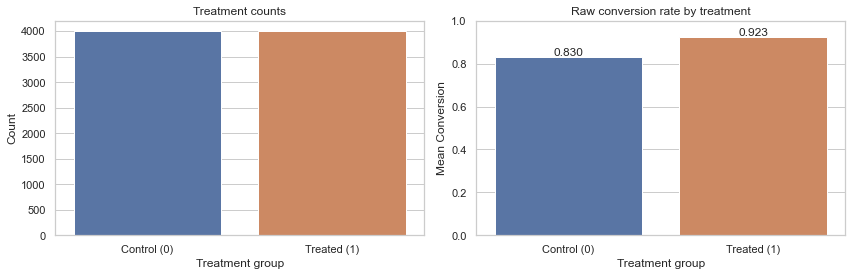

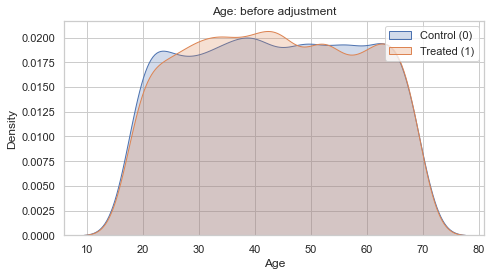

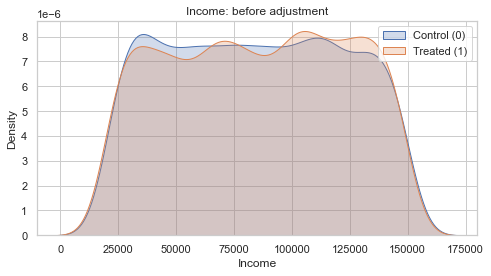

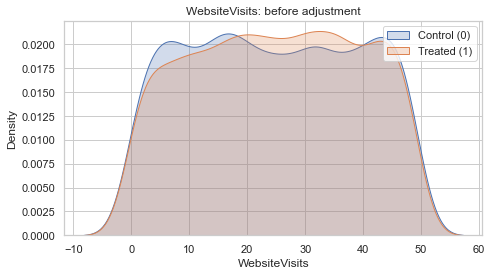

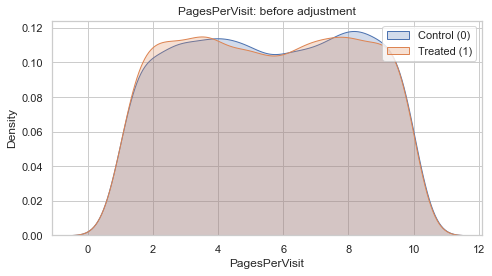

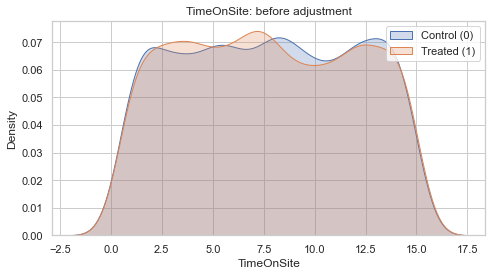

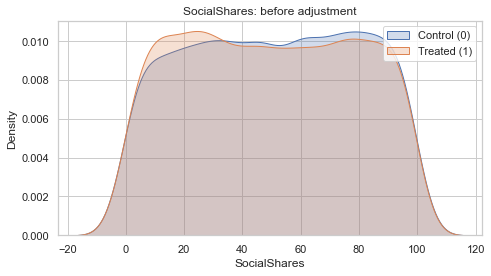

In [16]:
# Treatment / outcome overview
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Treatment counts
sns.countplot(data=work, x="treatment", ax=axes[0])
axes[0].set_title("Treatment counts")
axes[0].set_xlabel("Treatment group")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Control (0)", "Treated (1)"])

# Outcome by treatment
if outcome_type == "binary":
    outcome_summary = (
        work.groupby("treatment", as_index=False)[outcome_col]
        .mean()
        .rename(columns={outcome_col: "mean_outcome"})
    )

    sns.barplot(
        data=outcome_summary,
        x="treatment",
        y="mean_outcome",
        ax=axes[1]
    )
    axes[1].set_title("Raw conversion rate by treatment")
    axes[1].set_xlabel("Treatment group")
    axes[1].set_ylabel(f"Mean {outcome_col}")
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(["Control (0)", "Treated (1)"])
    axes[1].set_ylim(0, min(1.0, outcome_summary["mean_outcome"].max() * 1.15 + 0.02))

    # annotate bars
    for i, row in outcome_summary.iterrows():
        axes[1].text(
            i,
            row["mean_outcome"] + 0.01,
            f"{row['mean_outcome']:.3f}",
            ha="center"
        )
else:
    sns.boxplot(data=work, x="treatment", y=outcome_col, ax=axes[1])
    axes[1].set_title("Raw outcome distribution by treatment")
    axes[1].set_xlabel("Treatment group")
    axes[1].set_ylabel(outcome_col)
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(["Control (0)", "Treated (1)"])

plt.tight_layout()
plt.show()

# Show top numeric covariate distributions before adjustment
plot_cols = [col for col in numeric_covariates if col in work.columns][:6]

if len(plot_cols) == 0:
    print("No numeric covariates available for distribution plots.")
else:
    for col in plot_cols:
        plt.figure(figsize=(7, 4))

        treated = work.loc[work["treatment"] == 1, col].dropna()
        control = work.loc[work["treatment"] == 0, col].dropna()

        # Fall back to histogram if KDE is unstable or variable has too few unique values
        n_unique = work[col].nunique(dropna=True)

        if n_unique >= 10 and len(treated) > 1 and len(control) > 1:
            sns.kdeplot(control, label="Control (0)", fill=True)
            sns.kdeplot(treated, label="Treated (1)", fill=True)
            plt.title(f"{col}: before adjustment")
            plt.xlabel(col)
            plt.ylabel("Density")
            plt.legend()
        else:
            sns.histplot(
                data=work,
                x=col,
                hue="treatment",
                bins=20,
                stat="density",
                common_norm=False,
                element="step"
            )
            plt.title(f"{col}: before adjustment")
            plt.xlabel(col)
            plt.ylabel("Density")

        plt.tight_layout()
        plt.show()

In [17]:

naive_effect, naive_y1, naive_y0 = effect_from_groups(work, "treatment", outcome_col)
print("Naive difference in means / rates")
print({"ATE_like_difference": naive_effect, "treated_mean": naive_y1, "control_mean": naive_y0})

balance_before = compute_numeric_balance_table(work, "treatment", numeric_covariates)
display(balance_before.head(15))


Naive difference in means / rates
{'ATE_like_difference': 0.09249999999999992, 'treated_mean': 0.92275, 'control_mean': 0.83025}


,covariate,treated_mean,control_mean,abs_smd
6,EmailOpens,9.580250,9.373500,0.036205
5,SocialShares,49.282250,50.317250,0.035815
2,WebsiteVisits,24.923250,24.580000,0.023983
1,Income,85055.803000,84272.590500,0.020841
3,PagesPerVisit,5.529039,5.569559,0.015540
8,PreviousPurchases,4.504000,4.467000,0.012811
9,LoyaltyPoints,2498.652000,2481.885000,0.011729
4,TimeOnSite,7.710224,7.745212,0.008275
7,EmailClicks,4.460500,4.474250,0.004813
0,Age,43.656000,43.595000,0.004093


Propensity model ROC AUC: 0.5192


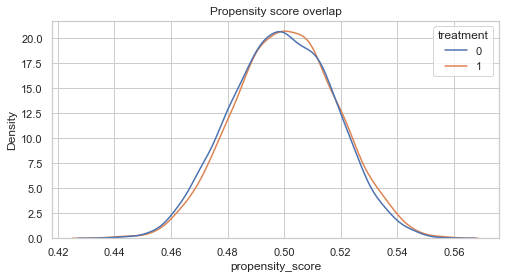

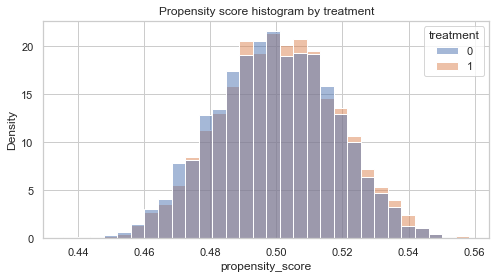

In [18]:

X = work[covariates]
t = work["treatment"].values
y = work[outcome_col].values

X_proc = preprocessor.fit_transform(X)

ps_model = LogisticRegression(max_iter=3000)
ps_model.fit(X_proc, t)
ps = ps_model.predict_proba(X_proc)[:, 1]

try:
    auc = roc_auc_score(t, ps)
    print("Propensity model ROC AUC:", round(auc, 4))
except Exception:
    pass

work = add_ps_logit(work, ps)

plt.figure(figsize=(8, 4))
sns.kdeplot(data=work, x="propensity_score", hue="treatment", common_norm=False)
plt.title("Propensity score overlap")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=work, x="propensity_score", hue="treatment", bins=30, stat="density", common_norm=False)
plt.title("Propensity score histogram by treatment")
plt.show()


IPW estimate
{'ATE': 0.09032808454641694, 'weighted_treated_mean': 0.9222756418809469, 'weighted_control_mean': 0.83194755733453}


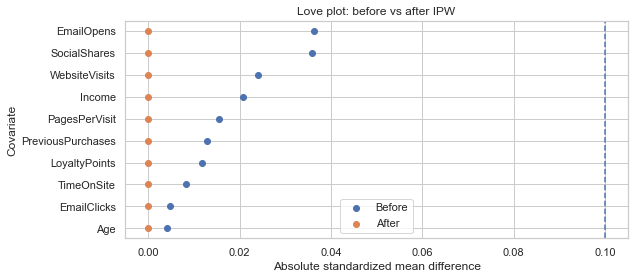

,covariate,abs_smd_before,abs_smd_after
0,EmailOpens,0.036205,0.000042
1,SocialShares,0.035815,0.000037
2,WebsiteVisits,0.023983,0.000047
3,Income,0.020841,0.000024
4,PagesPerVisit,0.015540,0.000008
5,PreviousPurchases,0.012811,0.000008
6,LoyaltyPoints,0.011729,0.000001
7,TimeOnSite,0.008275,0.000029
8,EmailClicks,0.004813,0.000018
9,Age,0.004093,0.000022


,treatment,weighted_mean_outcome
0,0,0.831948
1,1,0.922276


In [19]:

ipw_ate_est, ipw_weights, ipw_mu1, ipw_mu0 = ipw_ate(y, t, ps, stabilized=True)
work["ipw_weight"] = ipw_weights

print("IPW estimate")
print({"ATE": ipw_ate_est, "weighted_treated_mean": ipw_mu1, "weighted_control_mean": ipw_mu0})

balance_after_ipw = compute_numeric_balance_table(
    work,
    "treatment",
    numeric_covariates,
    weights=work["ipw_weight"]
)

love_ipw = plot_love(balance_before, balance_after_ipw, "Love plot: before vs after IPW")
display(love_ipw.head(15))

# Weighted outcome plot
if outcome_type == "binary":
    weighted_summary = (
        work.assign(weighted_outcome=work[outcome_col] * work["ipw_weight"])
        .groupby("treatment")
        .apply(lambda d: pd.Series({
            "weighted_mean_outcome": d["weighted_outcome"].sum() / d["ipw_weight"].sum()
        }))
        .reset_index()
    )
    display(weighted_summary)
else:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=work, x="treatment", y=outcome_col, whis=[5,95])
    plt.title("Outcome by treatment (raw boxplot; IPW summary shown in table)")
    plt.show()


Matching results
{'matched_pairs': 2171, 'ATE': 0.11008751727314603, 'matched_treated_mean': 0.9405803777061262, 'matched_control_mean': 0.8304928604329802}


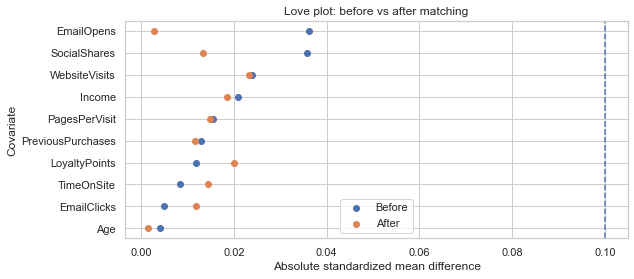

,covariate,abs_smd_before,abs_smd_after
0,EmailOpens,0.036205,0.002740
1,SocialShares,0.035815,0.013339
2,WebsiteVisits,0.023983,0.023183
3,Income,0.020841,0.018494
4,PagesPerVisit,0.015540,0.014735
5,PreviousPurchases,0.012811,0.011540
6,LoyaltyPoints,0.011729,0.020031
7,TimeOnSite,0.008275,0.014292
8,EmailClicks,0.004813,0.011720
9,Age,0.004093,0.001510


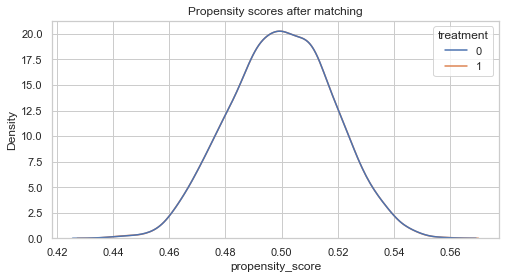

In [20]:

matched_df, pair_df = propensity_score_matching(
    work,
    treatment_col="treatment",
    outcome_col=outcome_col,
    caliper_std=CALIPER_STD,
    replacement=MATCH_REPLACEMENT
)

match_ate, match_y1, match_y0 = effect_from_groups(matched_df, "treatment", outcome_col)

print("Matching results")
print({
    "matched_pairs": len(pair_df),
    "ATE": match_ate,
    "matched_treated_mean": match_y1,
    "matched_control_mean": match_y0
})

balance_after_match = compute_numeric_balance_table(
    matched_df,
    "treatment",
    numeric_covariates
)

love_match = plot_love(balance_before, balance_after_match, "Love plot: before vs after matching")
display(love_match.head(15))

plt.figure(figsize=(8, 4))
sns.kdeplot(data=matched_df, x="propensity_score", hue="treatment", common_norm=False)
plt.title("Propensity scores after matching")
plt.show()


Doubly robust / AIPW estimate
{'ATE': 0.0900282360729596, 'mean_pred_if_treated': 0.9215423688912849, 'mean_pred_if_control': 0.8320010468574065}


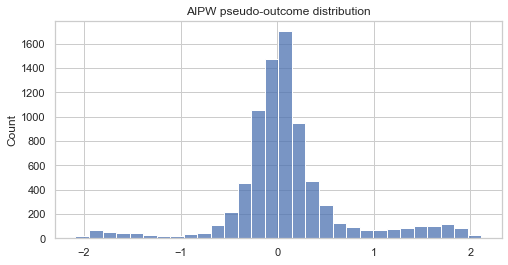

In [21]:

outcome_model, mu1_hat, mu0_hat = fit_outcome_models(X_proc, y, t, outcome_type)
dr_ate_est, pseudo_outcomes = aipw_ate(y, t, ps, mu1_hat, mu0_hat)

print("Doubly robust / AIPW estimate")
print({
    "ATE": dr_ate_est,
    "mean_pred_if_treated": float(np.mean(mu1_hat)),
    "mean_pred_if_control": float(np.mean(mu0_hat))
})

plt.figure(figsize=(8, 4))
sns.histplot(pseudo_outcomes, bins=30)
plt.title("AIPW pseudo-outcome distribution")
plt.show()


In [22]:

results = [
    {"method": "Naive difference", "estimate": naive_effect},
    {"method": "IPW", "estimate": ipw_ate_est},
    {"method": "PS Matching", "estimate": match_ate},
    {"method": "Doubly Robust (AIPW)", "estimate": dr_ate_est},
]
results_df = summarize_effects(results)
display(results_df)

# Final model on the full sample with IPW
model_df = work.copy()

if outcome_type == "binary":
    glm_ipw = smf.glm(
        formula=f"{outcome_col} ~ treatment",
        data=model_df,
        family=sm.families.Binomial(),
        freq_weights=model_df["ipw_weight"]
    ).fit()
    print(glm_ipw.summary())
else:
    wls_ipw = smf.wls(
        formula=f"{outcome_col} ~ treatment",
        data=model_df,
        weights=model_df["ipw_weight"]
    ).fit()
    print(wls_ipw.summary())

# Final model on matched sample
if outcome_type == "binary":
    glm_match = smf.glm(
        formula=f"{outcome_col} ~ treatment",
        data=matched_df,
        family=sm.families.Binomial()
    ).fit()
    print(glm_match.summary())
else:
    ols_match = smf.ols(
        formula=f"{outcome_col} ~ treatment",
        data=matched_df
    ).fit(cov_type="HC3")
    print(ols_match.summary())


,method,estimate
3,Doubly Robust (AIPW),0.090028
1,IPW,0.090328
0,Naive difference,0.092500
2,PS Matching,0.110088


                 Generalized Linear Model Regression Results                  
Dep. Variable:             Conversion   No. Observations:                 8000
Model:                            GLM   Df Residuals:                  7997.99
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2903.8
Date:                Sun, 12 Apr 2026   Deviance:                       5807.7
Time:                        00:56:28   Pearson chi2:                 8.00e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01914
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.5995      0.042     37.825      0.0

Analysis sample size: 8000
Treated proportion: 0.500
Outcome rate: 0.876

Final doubly robust result:


,estimand,method,estimate,std_error,p_value,ci90_lower,ci90_upper,ci95_lower,ci95_upper,treated_raw_mean,control_raw_mean,n
0,Average Treatment Effect (ATE),Doubly Robust / AIPW (cross-fitted),0.090829,0.006792,0.0,0.079657,0.102001,0.077517,0.104141,0.92275,0.83025,8000


Interpretation:
- Estimated ATE: 0.0908
  -> High ad spend changes conversion probability by about 9.08 percentage points on average.
- 90% CI: [0.0797, 0.1020]
- 95% CI: [0.0775, 0.1041]
- Two-sided p-value: 0

Bootstrap interval summary:


,method,estimate,boot_n_success,boot_ci90_lower,boot_ci90_upper,boot_ci95_lower,boot_ci95_upper
0,Bootstrap AIPW,0.090829,300,0.078571,0.102136,0.076467,0.104467


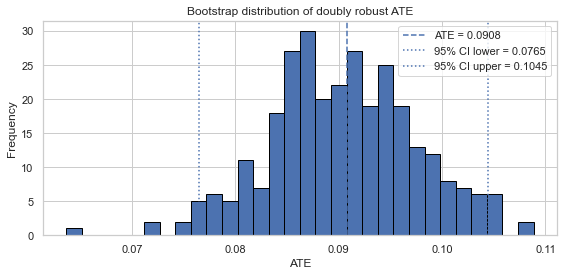

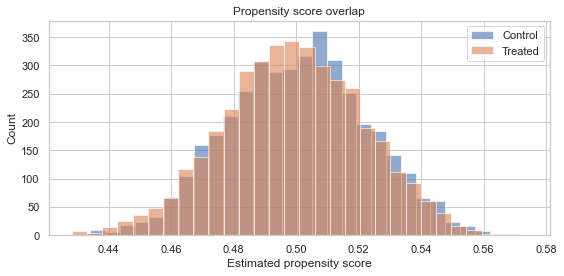

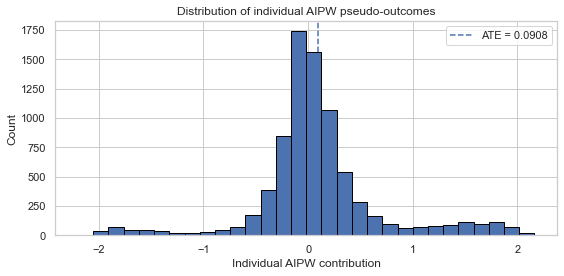

In [23]:
# ============================================================
# FINAL DOUBLY ROBUST (AIPW) ANALYSIS
# - Average treatment effect
# - Standard error
# - 90% and 95% confidence intervals
# - Two-sided p-value
# - Optional bootstrap intervals
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# ----------------------------
# Safety checks
# ----------------------------
if "treatment" not in work.columns:
    raise ValueError("Column 'treatment' not found in `work`.")

if outcome_col not in work.columns:
    raise ValueError(f"Outcome column '{outcome_col}' not found in `work`.")

if set(work["treatment"].dropna().unique()) - {0, 1}:
    raise ValueError("`work['treatment']` must be binary with values 0/1.")

if set(work[outcome_col].dropna().unique()) - {0, 1}:
    raise ValueError(f"`work['{outcome_col}']` must be binary with values 0/1.")

# ----------------------------
# Prepare modeling data
# ----------------------------
analysis_df = work[["treatment", outcome_col] + covariates].dropna().copy()
analysis_df["treatment"] = analysis_df["treatment"].astype(int)
analysis_df[outcome_col] = analysis_df[outcome_col].astype(int)

X = analysis_df[covariates].copy()
T = analysis_df["treatment"].to_numpy().astype(int)
Y = analysis_df[outcome_col].to_numpy().astype(float)
n = len(analysis_df)

print(f"Analysis sample size: {n}")
print(f"Treated proportion: {T.mean():.3f}")
print(f"Outcome rate: {Y.mean():.3f}")

# ----------------------------
# Build preprocessors
# ----------------------------
numeric_features = [c for c in numeric_covariates if c in covariates]
categorical_features = [c for c in categorical_covariates if c in covariates]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# ----------------------------
# Cross-fitted AIPW estimator
# ----------------------------
def crossfit_aipw(X, T, Y, preprocessor, n_splits=5, clip=0.01, random_state=42):
    """
    Cross-fitted AIPW estimator for binary treatment and binary outcome.
    Returns:
        ate, se, pvalue, ci90, ci95, influence_values, nuisance_preds
    """
    n = len(Y)
    e_hat = np.zeros(n)   # propensity P(T=1|X)
    m1_hat = np.zeros(n)  # E[Y|T=1,X]
    m0_hat = np.zeros(n)  # E[Y|T=0,X]

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, T), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        T_train = T[train_idx]
        Y_train = Y[train_idx]

        # Propensity model
        prop_model = Pipeline(steps=[
            ("prep", preprocessor),
            ("model", LogisticRegression(max_iter=5000, solver="lbfgs"))
        ])
        prop_model.fit(X_train, T_train)
        e_hat[test_idx] = prop_model.predict_proba(X_test)[:, 1]

        # Outcome model for treated
        outcome_model_treated = Pipeline(steps=[
            ("prep", preprocessor),
            ("model", LogisticRegression(max_iter=5000, solver="lbfgs"))
        ])
        outcome_model_treated.fit(X_train.loc[T_train == 1], Y_train[T_train == 1])
        m1_hat[test_idx] = outcome_model_treated.predict_proba(X_test)[:, 1]

        # Outcome model for control
        outcome_model_control = Pipeline(steps=[
            ("prep", preprocessor),
            ("model", LogisticRegression(max_iter=5000, solver="lbfgs"))
        ])
        outcome_model_control.fit(X_train.loc[T_train == 0], Y_train[T_train == 0])
        m0_hat[test_idx] = outcome_model_control.predict_proba(X_test)[:, 1]

    # Clip propensity scores for stability
    e_hat = np.clip(e_hat, clip, 1 - clip)

    # Individual AIPW pseudo-outcomes
    aipw_i = (
        (m1_hat - m0_hat)
        + T * (Y - m1_hat) / e_hat
        - (1 - T) * (Y - m0_hat) / (1 - e_hat)
    )

    ate = aipw_i.mean()
    se = aipw_i.std(ddof=1) / np.sqrt(n)
    z_stat = ate / se
    pvalue = 2 * (1 - norm.cdf(abs(z_stat)))

    ci90 = (ate - norm.ppf(0.95) * se, ate + norm.ppf(0.95) * se)
    ci95 = (ate - norm.ppf(0.975) * se, ate + norm.ppf(0.975) * se)

    nuisance = {
        "propensity_score": e_hat,
        "mu1_hat": m1_hat,
        "mu0_hat": m0_hat,
        "aipw_individual": aipw_i
    }

    return ate, se, pvalue, ci90, ci95, nuisance

ate, se, pvalue, ci90, ci95, nuisance = crossfit_aipw(
    X=X,
    T=T,
    Y=Y,
    preprocessor=preprocessor,
    n_splits=5,
    clip=0.01,
    random_state=42
)

# ----------------------------
# Convert to treated/control means for reporting
# ----------------------------
treated_rate = analysis_df.loc[analysis_df["treatment"] == 1, outcome_col].mean()
control_rate = analysis_df.loc[analysis_df["treatment"] == 0, outcome_col].mean()

# ----------------------------
# Main result table
# ----------------------------
results_dr = pd.DataFrame({
    "estimand": ["Average Treatment Effect (ATE)"],
    "method": ["Doubly Robust / AIPW (cross-fitted)"],
    "estimate": [ate],
    "std_error": [se],
    "p_value": [pvalue],
    "ci90_lower": [ci90[0]],
    "ci90_upper": [ci90[1]],
    "ci95_lower": [ci95[0]],
    "ci95_upper": [ci95[1]],
    "treated_raw_mean": [treated_rate],
    "control_raw_mean": [control_rate],
    "n": [n]
})

print("\nFinal doubly robust result:")
display(results_dr)

# ----------------------------
# Human-readable summary
# ----------------------------
print("Interpretation:")
print(f"- Estimated ATE: {ate:.4f}")
print(f"  -> High ad spend changes conversion probability by about {ate*100:.2f} percentage points on average.")
print(f"- 90% CI: [{ci90[0]:.4f}, {ci90[1]:.4f}]")
print(f"- 95% CI: [{ci95[0]:.4f}, {ci95[1]:.4f}]")
print(f"- Two-sided p-value: {pvalue:.6g}")

# ----------------------------
# Optional: bootstrap confidence intervals
# ----------------------------
def bootstrap_aipw(X, T, Y, preprocessor, n_boot=300, n_splits=5, clip=0.01, random_state=42):
    rng = np.random.default_rng(random_state)
    boot_ates = []

    for b in range(n_boot):
        idx = rng.integers(0, len(Y), len(Y))
        X_b = X.iloc[idx].reset_index(drop=True)
        T_b = T[idx]
        Y_b = Y[idx]

        try:
            ate_b, _, _, _, _, _ = crossfit_aipw(
                X=X_b,
                T=T_b,
                Y=Y_b,
                preprocessor=preprocessor,
                n_splits=n_splits,
                clip=clip,
                random_state=random_state + b + 1
            )
            boot_ates.append(ate_b)
        except Exception:
            continue

    boot_ates = np.array(boot_ates)
    return boot_ates

RUN_BOOTSTRAP = True

if RUN_BOOTSTRAP:
    boot_ates = bootstrap_aipw(
        X=X,
        T=T,
        Y=Y,
        preprocessor=preprocessor,
        n_boot=300,      # increase to 500 or 1000 if desired
        n_splits=5,
        clip=0.01,
        random_state=42
    )

    if len(boot_ates) > 30:
        boot_ci90 = np.quantile(boot_ates, [0.05, 0.95])
        boot_ci95 = np.quantile(boot_ates, [0.025, 0.975])

        bootstrap_summary = pd.DataFrame({
            "method": ["Bootstrap AIPW"],
            "estimate": [ate],
            "boot_n_success": [len(boot_ates)],
            "boot_ci90_lower": [boot_ci90[0]],
            "boot_ci90_upper": [boot_ci90[1]],
            "boot_ci95_lower": [boot_ci95[0]],
            "boot_ci95_upper": [boot_ci95[1]]
        })

        print("\nBootstrap interval summary:")
        display(bootstrap_summary)

        plt.figure(figsize=(8, 4))
        plt.hist(boot_ates, bins=30, edgecolor="black")
        plt.axvline(ate, linestyle="--", label=f"ATE = {ate:.4f}")
        plt.axvline(boot_ci95[0], linestyle=":", label=f"95% CI lower = {boot_ci95[0]:.4f}")
        plt.axvline(boot_ci95[1], linestyle=":", label=f"95% CI upper = {boot_ci95[1]:.4f}")
        plt.title("Bootstrap distribution of doubly robust ATE")
        plt.xlabel("ATE")
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Bootstrap did not produce enough successful replications.")

# ----------------------------
# Diagnostic plots
# ----------------------------
diag = analysis_df.copy()
diag["propensity_score"] = nuisance["propensity_score"]
diag["mu1_hat"] = nuisance["mu1_hat"]
diag["mu0_hat"] = nuisance["mu0_hat"]
diag["aipw_individual"] = nuisance["aipw_individual"]

# Propensity overlap
plt.figure(figsize=(8, 4))
plt.hist(diag.loc[diag["treatment"] == 0, "propensity_score"], bins=30, alpha=0.6, label="Control")
plt.hist(diag.loc[diag["treatment"] == 1, "propensity_score"], bins=30, alpha=0.6, label="Treated")
plt.title("Propensity score overlap")
plt.xlabel("Estimated propensity score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# Individual AIPW score distribution
plt.figure(figsize=(8, 4))
plt.hist(diag["aipw_individual"], bins=30, edgecolor="black")
plt.axvline(ate, linestyle="--", label=f"ATE = {ate:.4f}")
plt.title("Distribution of individual AIPW pseudo-outcomes")
plt.xlabel("Individual AIPW contribution")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
print(
    f"The doubly robust AIPW estimate of the average treatment effect is {ate:.4f}, "
    f"with a 90% CI of [{ci90[0]:.4f}, {ci90[1]:.4f}] and a 95% CI of [{ci95[0]:.4f}, {ci95[1]:.4f}]. "
    f"The two-sided p-value is {pvalue:.10f}."
)

The doubly robust AIPW estimate of the average treatment effect is 0.0908, with a 90% CI of [0.0797, 0.1020] and a 95% CI of [0.0775, 0.1041]. The two-sided p-value is 0.0000000000.
